# Dataset Analysis — Pre-Tokenization Quality Check

Analyzes the 4 model-ready datasets and produces:
- Class distribution analysis and charts
- Token length analysis with ModernBERT tokenizer
- Recommended max_length per task
- Health score report

**Input:** `data/model_ready/` (from notebook 5)
**Output:** `reports/` (JSON config, CSV reports, PNG charts)

In [30]:
import json
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [31]:
# ── Paths and settings ──
DATA_DIR = Path("data/model_ready")
REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "answerdotai/ModernBERT-base"
TRUNC_LENGTHS = [64, 96, 128, 256, 512]

# Dataset specs — exact column names from the model-ready files
DATASET_SPECS = {
    "intent": {
        "path": DATA_DIR / "intent_encoded.csv",
        "text_col": "text",
        "label_col": "intent_label",
        "name_col": "intent",
    },
    "root_cause": {
        "path": DATA_DIR / "root_cause_encoded.csv",
        "text_col": "text",
        "label_col": "root_cause_label",
        "name_col": "root_cause",
    },
    "sentiment": {
        "path": DATA_DIR / "sentiment_encoded.csv",
        "text_col": "text",
        "label_col": "sentiment_label",
        "name_col": "sentiment",
    },
    "risk": {
        "path": DATA_DIR / "risk_dataset.csv",
        "text_col": "text",
        "label_col": "risk_label",
        "name_col": "risk_band",
    },
}

print("Configuration set")
print(f"  Data dir  : {DATA_DIR}")
print(f"  Report dir: {REPORT_DIR}")
print(f"  Model     : {MODEL_NAME}")

Configuration set
  Data dir  : data\model_ready
  Report dir: reports
  Model     : answerdotai/ModernBERT-base


In [32]:
# ── Load all 4 datasets ──
datasets = {}
for name, spec in DATASET_SPECS.items():
    df = pd.read_csv(spec["path"])
    datasets[name] = df
    print(f"  Loaded {name:12s}  ->  {len(df):>6,} rows   columns: {list(df.columns)}")

  Loaded intent        ->  20,043 rows   columns: ['text', 'intent', 'intent_label']
  Loaded root_cause    ->  11,594 rows   columns: ['text', 'root_cause', 'root_cause_label']
  Loaded sentiment     ->  16,432 rows   columns: ['text', 'sentiment', 'sentiment_label']
  Loaded risk          ->  11,594 rows   columns: ['text', 'risk_score', 'risk_band', 'risk_label']


In [33]:
# ── Dataset summary ──
for name, df in datasets.items():
    spec = DATASET_SPECS[name]
    n_classes = df[spec["name_col"]].nunique()
    n_labels = df[spec["label_col"]].nunique()
    mem_kb = df.memory_usage(deep=True).sum() / 1024
    print(f"  {name:12s}  {len(df):>6,} rows  {n_classes:>3} classes  {n_labels:>3} label IDs  {mem_kb:>8.1f} KB")
    
    if n_classes != n_labels:
        print(f"    WARNING: class names ({n_classes}) != label IDs ({n_labels}) — check encoding")

  intent        20,043 rows   19 classes   19 label IDs    5054.5 KB
  root_cause    11,594 rows   26 classes   26 label IDs    3529.1 KB
  sentiment     16,432 rows    4 classes    4 label IDs    4615.2 KB
  risk          11,594 rows    5 classes    5 label IDs    3475.7 KB


In [34]:
# ── Missing and empty value check ──
all_clean = True

for name, df in datasets.items():
    spec = DATASET_SPECS[name]
    text_col = spec["text_col"]
    label_col = spec["label_col"]
    name_col = spec["name_col"]

    missing_text = df[text_col].isna().sum()
    empty_text = (df[text_col].astype(str).str.strip() == "").sum()
    missing_label = df[label_col].isna().sum()
    missing_name = df[name_col].isna().sum()

    is_clean = (missing_text + empty_text + missing_label + missing_name) == 0
    if not is_clean:
        all_clean = False


    print(f"    Missing text     : {missing_text}")
    print(f"    Empty text       : {empty_text}")
    print(f"    Missing label_id : {missing_label}")
    print(f"    Missing name     : {missing_name}")


    Missing text     : 0
    Empty text       : 0
    Missing label_id : 0
    Missing name     : 0
    Missing text     : 0
    Empty text       : 0
    Missing label_id : 0
    Missing name     : 0
    Missing text     : 0
    Empty text       : 0
    Missing label_id : 0
    Missing name     : 0
    Missing text     : 0
    Empty text       : 0
    Missing label_id : 0
    Missing name     : 0


In [35]:
# ── Duplicate text check ──
for name, df in datasets.items():
    text_col = DATASET_SPECS[name]["text_col"]
    total = len(df)
    n_dup = df[text_col].duplicated(keep=False).sum()
    pct = n_dup / total * 100
    
    print(f" duplicates: {n_dup:,} ")

 duplicates: 0 
 duplicates: 0 
 duplicates: 0 
 duplicates: 0 


CLASS DISTRIBUTION — intent
  complaint                             4,598   22.9%  #########
  praise                                3,439   17.2%  ######
  payment_failure                       1,698    8.5%  ###
  feature_request                       1,450    7.2%  ##
  technical_failure                     1,332    6.6%  ##
  access_blocked                        1,227    6.1%  ##
  refund_request                        1,055    5.3%  ##
  data_integrity_issue                    987    4.9%  #
  ux_friction                             941    4.7%  #
  noise                                   874    4.4%  #
  fx_conversion_complaint                 677    3.4%  #
  security_concern                        407    2.0%  
  regulatory_risk                         328    1.6%  
  service_quality                         253    1.3%  
  interbank_transfer_failure              212    1.1%  
  account_closure                         192    1.0%  
  competitor_switch                       138 

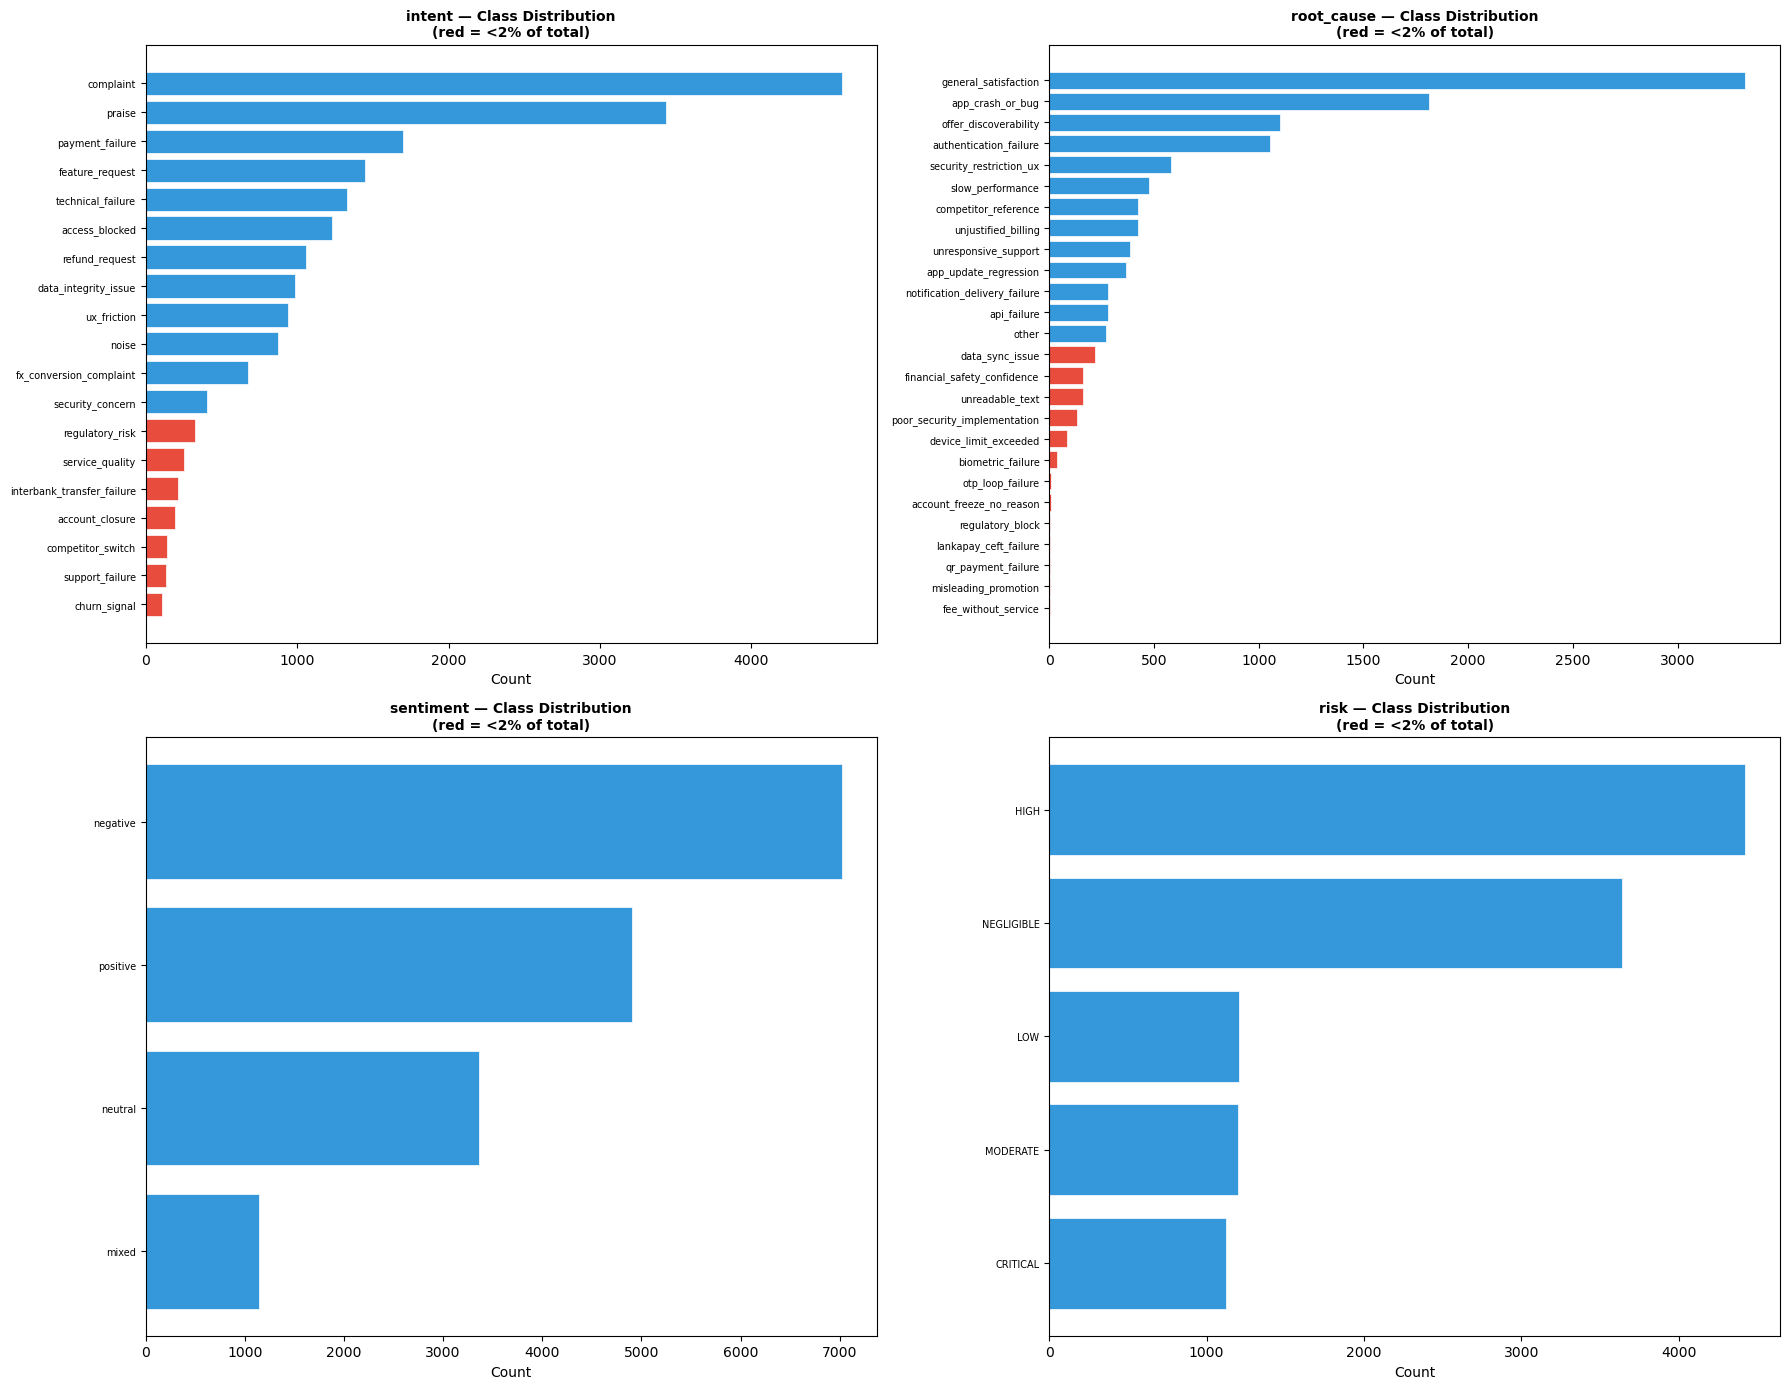

Saved -> reports\class_distribution.png


In [42]:
# ── Class distribution analysis + charts ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

dist_records = {}  # store for health check later

for idx, (name, df) in enumerate(datasets.items()):
    name_col = DATASET_SPECS[name]["name_col"]
    ax = axes[idx]
    counts = df[name_col].value_counts().sort_values(ascending=True)
    total = len(df)
    dist_records[name] = counts

    # Print table

    print(f"CLASS DISTRIBUTION — {name}")
 
    for cls, cnt in counts.sort_values(ascending=False).items():
        bar = "#" * int(cnt / total * 40)
        print(f"  {str(cls)[:35]:35s}  {cnt:6,}  {cnt/total*100:5.1f}%  {bar}")
    
    imbalance = counts.max() / counts.min() if counts.min() > 0 else float("inf")
    print(f"\n  Imbalance ratio: {imbalance:.1f}x")
    print(f"  Classes with < 50 samples: {(counts < 50).sum()}")
    print()

    # Bar chart
    colors = ["#e74c3c" if c/total < 0.02 else "#3498db" for c in counts.values]
    ax.barh(range(len(counts)), counts.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels([str(c)[:30] for c in counts.index], fontsize=7)
    ax.set_xlabel("Count")
    ax.set_title(f"{name} — Class Distribution\n(red = <2% of total)", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(REPORT_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORT_DIR / 'class_distribution.png'}")

LENGTH ANALYSIS — intent
  Character: min=13, mean=94.9, p90=209, max=1795
  Word:      min=3, mean=17.5, p90=38, max=319

LENGTH ANALYSIS — root_cause
  Character: min=14, mean=120.1, p90=276, max=1795
  Word:      min=5, mean=21.6, p90=49, max=319

LENGTH ANALYSIS — sentiment
  Character: min=9, mean=122.4, p90=244, max=1795
  Word:      min=2, mean=22.0, p90=44, max=319

LENGTH ANALYSIS — risk
  Character: min=14, mean=120.1, p90=276, max=1795
  Word:      min=5, mean=21.6, p90=49, max=319



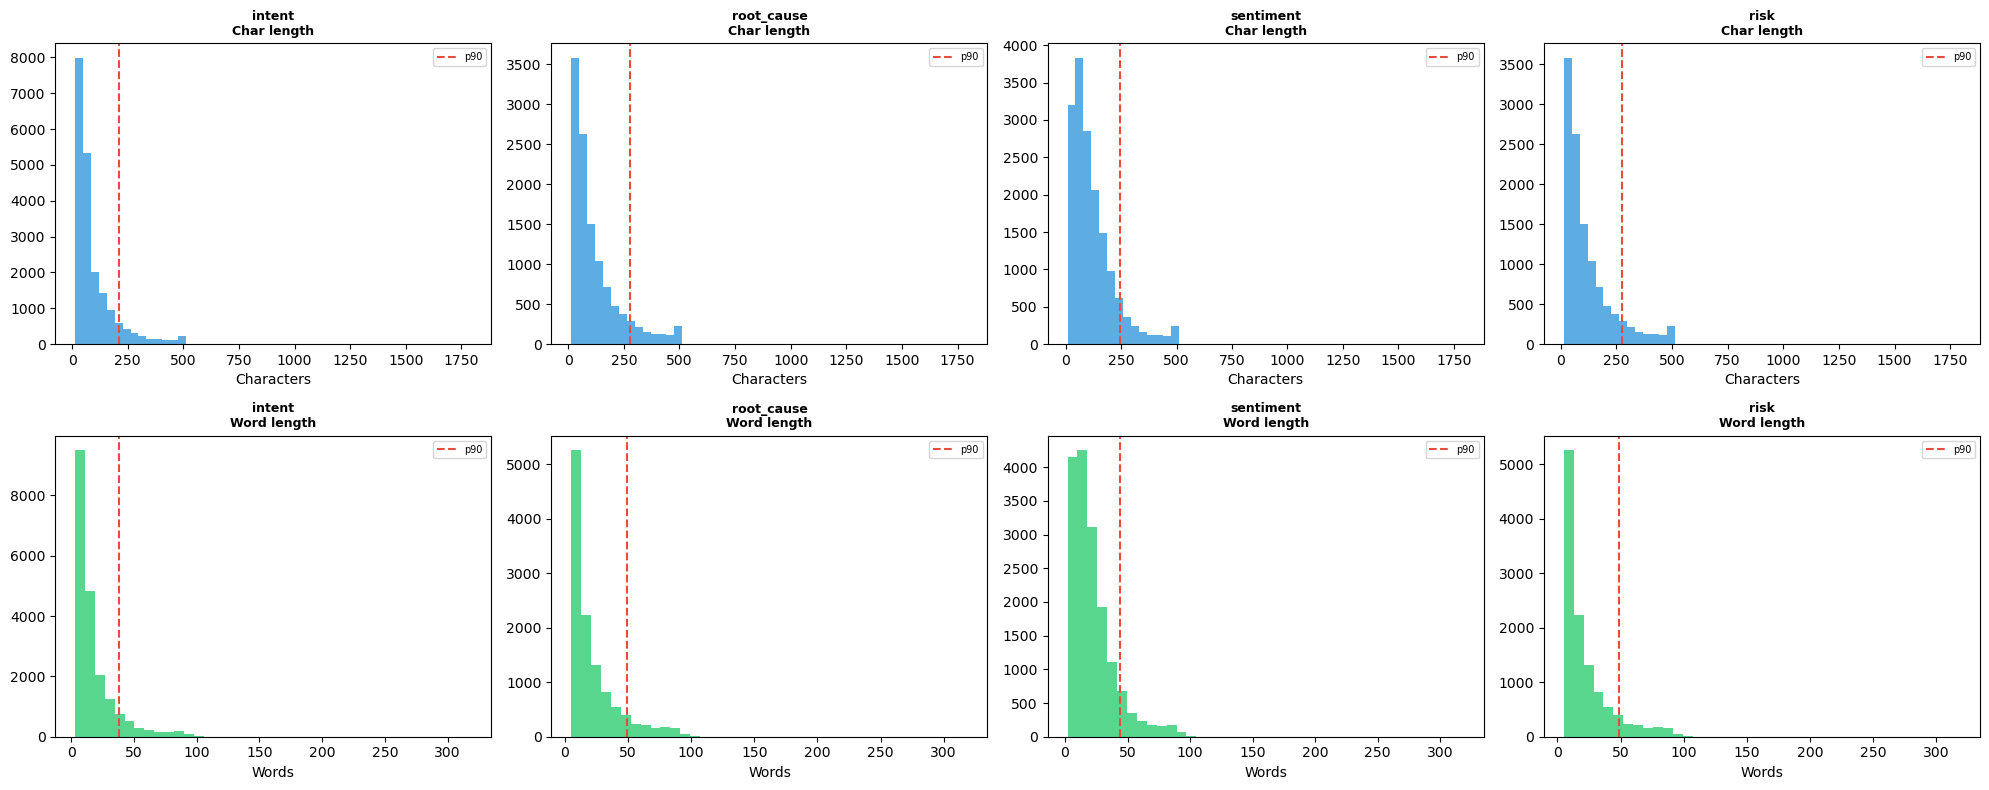

In [37]:
# ── Character and word length analysis ──
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (name, df) in enumerate(datasets.items()):
    text_col = DATASET_SPECS[name]["text_col"]
    texts = df[text_col].astype(str)
    char_lens = texts.str.len()
    word_lens = texts.str.split().str.len()


    print(f"LENGTH ANALYSIS — {name}")

    print(f"  Character: min={char_lens.min()}, mean={char_lens.mean():.1f}, p90={char_lens.quantile(0.90):.0f}, max={char_lens.max()}")
    print(f"  Word:      min={word_lens.min()}, mean={word_lens.mean():.1f}, p90={word_lens.quantile(0.90):.0f}, max={word_lens.max()}")
    print()

    # Character histogram
    ax_c = axes[0][idx]
    ax_c.hist(char_lens, bins=50, color="#3498db", edgecolor="none", alpha=0.8)
    ax_c.axvline(char_lens.quantile(0.90), color="#e74c3c", linestyle="--", label="p90")
    ax_c.set_title(f"{name}\nChar length", fontsize=9, fontweight="bold")
    ax_c.set_xlabel("Characters")
    ax_c.legend(fontsize=7)

    # Word histogram
    ax_w = axes[1][idx]
    ax_w.hist(word_lens, bins=40, color="#2ecc71", edgecolor="none", alpha=0.8)
    ax_w.axvline(word_lens.quantile(0.90), color="#e74c3c", linestyle="--", label="p90")
    ax_w.set_title(f"{name}\nWord length", fontsize=9, fontweight="bold")
    ax_w.set_xlabel("Words")
    ax_w.legend(fontsize=7)

plt.tight_layout()
plt.savefig(REPORT_DIR / "length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [38]:
# ── Tokenize all texts with ModernBERT to get subword token lengths ──

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded (vocab size: {tokenizer.vocab_size:,})")
print()

token_stats = {}

for name, df in datasets.items():
    text_col = DATASET_SPECS[name]["text_col"]
    texts = df[text_col].astype(str).tolist()
    print(f"Tokenizing {name} ({len(texts):,} texts) ...", end=" ", flush=True)

    encodings = tokenizer(texts, add_special_tokens=True, truncation=False, padding=False, return_attention_mask=False)
    tok_lengths = np.array([len(ids) for ids in encodings["input_ids"]])

    token_stats[name] = {
        "min": int(tok_lengths.min()),
        "mean": float(tok_lengths.mean()),
        "p90": float(np.percentile(tok_lengths, 90)),
        "p95": float(np.percentile(tok_lengths, 95)),
        "p98": float(np.percentile(tok_lengths, 98)),
        "max": int(tok_lengths.max()),
        "tok_lengths": tok_lengths,
    }
    print(f"done  min={token_stats[name]['min']}  mean={token_stats[name]['mean']:.1f}  p95={token_stats[name]['p95']:.0f}  max={token_stats[name]['max']}")

Tokenizer loaded (vocab size: 50,280)

Tokenizing intent (20,043 texts) ... done  min=5  mean=27.6  p95=75  max=1226
Tokenizing root_cause (11,594 texts) ... done  min=7  mean=36.2  p95=96  max=1226
Tokenizing sentiment (16,432 texts) ... done  min=4  mean=34.6  p95=83  max=1226
Tokenizing risk (11,594 texts) ... done  min=7  mean=36.2  p95=96  max=1226


In [39]:
# ── Truncation analysis at different max_length values ──

trunc_table = {}
header = f"{'Dataset':<15s}" + "".join(f"  {L:>6}tok" for L in TRUNC_LENGTHS)
print(header)
print("-" * len(header))

for name, stats in token_stats.items():
    tok_lengths = stats["tok_lengths"]
    row_vals = {}
    row_str = f"{name:<15s}"
    for L in TRUNC_LENGTHS:
        pct = (tok_lengths > L).sum() / len(tok_lengths) * 100
        row_vals[L] = round(pct, 2)
        if pct < 2:
            tag = f" {pct:5.2f}% OK"
        elif pct < 5:
            tag = f" {pct:5.2f}% WARN"
        else:
            tag = f" {pct:5.2f}% HIGH"
        row_str += tag
    trunc_table[name] = row_vals
    print(row_str)

print()

Dataset              64tok      96tok     128tok     256tok     512tok
----------------------------------------------------------------------
intent           6.53% HIGH  2.89% WARN  1.15% OK  0.67% OK  0.32% OK
root_cause      11.08% HIGH  5.00% HIGH  1.98% OK  1.16% OK  0.56% OK
sentiment        8.44% HIGH  3.55% WARN  1.41% OK  0.82% OK  0.40% OK
risk            11.08% HIGH  5.00% HIGH  1.98% OK  1.16% OK  0.56% OK



In [40]:
# ── Pick best max_length per dataset ──
TARGET_TRUNC_PCT = 1.5
recommendations = {}


for name, row_vals in trunc_table.items():
    chosen_len = None
    chosen_pct = None
    for L in TRUNC_LENGTHS:
        if row_vals[L] <= TARGET_TRUNC_PCT:
            chosen_len = L
            chosen_pct = row_vals[L]
            break
    if chosen_len is None:
        chosen_len = TRUNC_LENGTHS[-1]
        chosen_pct = row_vals[chosen_len]

    p95 = token_stats[name]["p95"]
    recommendations[name] = {
        "max_length": chosen_len,
        "truncate_pct": chosen_pct,
        "p95_token_length": round(p95, 1),
        "rationale": f"At max_length={chosen_len}, only {chosen_pct:.2f}% of reviews are truncated. p95 token length is {p95:.0f}.",
    }
    print(f"\n  {name.upper()}")
    print(f"    Recommended max_length : {chosen_len}")
    print(f"    Truncation             : {chosen_pct:.2f}%")
    print(f"    p95 token length       : {p95:.0f}")


  INTENT
    Recommended max_length : 128
    Truncation             : 1.15%
    p95 token length       : 75

  ROOT_CAUSE
    Recommended max_length : 256
    Truncation             : 1.16%
    p95 token length       : 96

  SENTIMENT
    Recommended max_length : 128
    Truncation             : 1.41%
    p95 token length       : 83

  RISK
    Recommended max_length : 256
    Truncation             : 1.16%
    p95 token length       : 96


In [41]:
# ── Save all reports ──

# 1. recommended_tokenization.json
json_path = REPORT_DIR / "recommended_tokenization.json"
with open(json_path, "w") as f:
    json.dump(recommendations, f, indent=4)
print(f"Saved -> {json_path}")

# 2. dataset_analysis_report.csv
analysis_rows = []
for name, df in datasets.items():
    text_col = DATASET_SPECS[name]["text_col"]
    name_col = DATASET_SPECS[name]["name_col"]
    ts = token_stats[name]
    rec = recommendations[name]
    analysis_rows.append({
        "dataset": name,
        "rows": len(df),
        "unique_classes": df[name_col].nunique(),
        "missing_text": df[text_col].isna().sum(),
        "empty_text": (df[text_col].astype(str).str.strip() == "").sum(),
        "dup_texts": df[text_col].duplicated(keep=False).sum(),
        "token_min": ts["min"],
        "token_mean": round(ts["mean"], 1),
        "token_p90": round(ts["p90"], 1),
        "token_p95": round(ts["p95"], 1),
        "token_p98": round(ts["p98"], 1),
        "token_max": ts["max"],
        "recommended_max_len": rec["max_length"],
        "truncate_pct": rec["truncate_pct"],
    })
pd.DataFrame(analysis_rows).to_csv(REPORT_DIR / "dataset_analysis_report.csv", index=False)
print(f"Saved -> {REPORT_DIR / 'dataset_analysis_report.csv'}")

# 3. class_distribution.csv
dist_rows = []
for name, df in datasets.items():
    name_col = DATASET_SPECS[name]["name_col"]
    label_col = DATASET_SPECS[name]["label_col"]
    total = len(df)
    counts = df.groupby([name_col, label_col]).size().reset_index(name="count")
    counts["dataset"] = name
    counts["pct"] = (counts["count"] / total * 100).round(2)
    dist_rows.append(counts)
pd.concat(dist_rows, ignore_index=True).to_csv(REPORT_DIR / "class_distribution.csv", index=False)
print(f"Saved -> {REPORT_DIR / 'class_distribution.csv'}")

Saved -> reports\recommended_tokenization.json
Saved -> reports\dataset_analysis_report.csv
Saved -> reports\class_distribution.csv
